
1. Decision Tree - Student Performance Prediction
2. Decision Tree -  Loan Approval Prediction
3. DBSCAN - Customer Segmentation
4. DBSCAN - Geographic Hotspot Detection



In [1]:
# Common imports used across all projects
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, silhouette_score)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import DBSCAN, KMeans
from sklearn.neighbors import NearestNeighbors

import os
os.makedirs('figs', exist_ok=True)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)


---
# Project 1: Decision Tree - Student Performance Prediction

**Dataset:** `student_performance.csv` (40 records, 7 columns)

**Goal:** Predict whether a student will Pass or Fail based on study habits, attendance, prior grades, sleep, and extra classes.

## 1. Data Exploration

In [3]:
df1 = pd.read_csv('student_performance.csv')
print("Shape:", df1.shape)
df1.head(10)

Shape: (40, 7)


,StudentID,StudyHours,Attendance,PreviousGrade,SleepHours,ExtraClasses,Result
0,S001,2,55,45,5,No,Fail
1,S002,6,85,72,7,Yes,Pass
2,S003,8,92,85,7,Yes,Pass
3,S004,1,40,38,4,No,Fail
4,S005,5,78,68,6,No,Pass
5,S006,7,88,80,8,Yes,Pass
6,S007,3,60,50,5,No,Fail
7,S008,4,70,62,6,Yes,Pass
8,S009,2,50,42,5,No,Fail
9,S010,9,95,90,8,Yes,Pass


In [5]:
df1.columns

Index(['StudentID', 'StudyHours', 'Attendance', 'PreviousGrade', 'SleepHours',
       'ExtraClasses', 'Result'],
      dtype='object')

In [6]:
df1.describe(include='all')

,StudentID,StudyHours,Attendance,PreviousGrade,SleepHours,ExtraClasses,Result
count,40,40.000000,40.000000,40.000000,40.000000,40,40
unique,40,NaN,NaN,NaN,NaN,2,2
top,S001,NaN,NaN,NaN,NaN,Yes,Pass
freq,1,NaN,NaN,NaN,NaN,21,24
mean,NaN,4.900000,72.450000,64.225000,6.150000,NaN,NaN
std,NaN,2.372924,17.391348,17.197924,1.311683,NaN,NaN
min,NaN,1.000000,38.000000,35.000000,4.000000,NaN,NaN
25%,NaN,3.000000,57.750000,47.750000,5.000000,NaN,NaN
50%,NaN,5.000000,76.500000,66.500000,6.000000,NaN,NaN
75%,NaN,7.000000,87.250000,79.250000,7.000000,NaN,NaN


In [7]:
print("Missing values per column:")
print(df1.isnull().sum())
print("\nResult class balance:")
print(df1['Result'].value_counts())

Missing values per column:
StudentID        0
StudyHours       0
Attendance       0
PreviousGrade    0
SleepHours       0
ExtraClasses     0
Result           0
dtype: int64

Result class balance:
Result
Pass    24
Fail    16
Name: count, dtype: int64


**Observation:** The dataset has 40 records and no missing values. The target `Result` is moderately imbalanced (24 Pass / 16 Fail).

## 2. Data Visualization

C:\Users\hp\AppData\Local\Temp\ipykernel_14032\3629502952.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1, x='Result', y='StudyHours', ax=axes[0], palette='Set2')


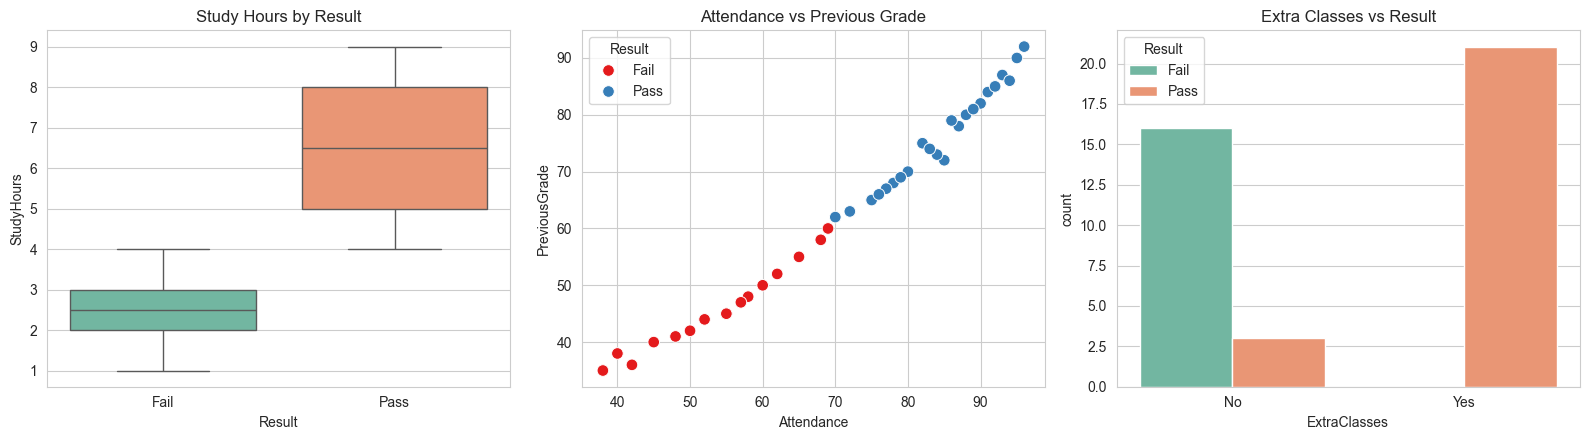

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.boxplot(data=df1, x='Result', y='StudyHours', ax=axes[0], palette='Set2')
axes[0].set_title('Study Hours by Result')

sns.scatterplot(data=df1, x='Attendance', y='PreviousGrade', hue='Result', ax=axes[1], palette='Set1', s=70)
axes[1].set_title('Attendance vs Previous Grade')

sns.countplot(data=df1, x='ExtraClasses', hue='Result', ax=axes[2], palette='Set2')
axes[2].set_title('Extra Classes vs Result')

plt.tight_layout()
plt.savefig('figs/p1_exploration.png', dpi=120, bbox_inches='tight')
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_14032\3777362058.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1, x='Result', y='SleepHours', palette='Set3', ax=ax)


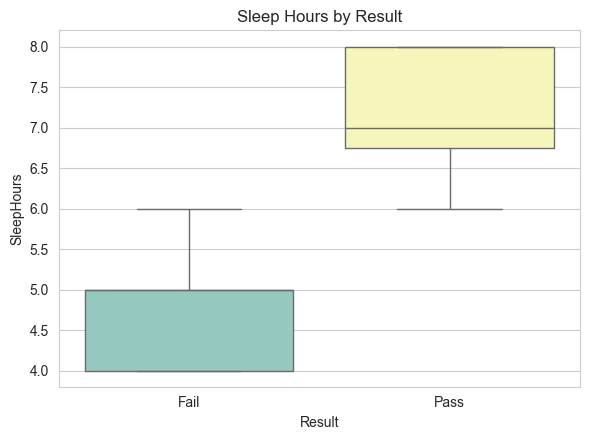

In [9]:
fig, ax = plt.subplots(figsize=(6,4.5))
sns.boxplot(data=df1, x='Result', y='SleepHours', palette='Set3', ax=ax)
ax.set_title('Sleep Hours by Result')
plt.tight_layout()
plt.savefig('figs/p1_sleep.png', dpi=120, bbox_inches='tight')
plt.show()

**Insight:** Passing students tend to study more hours, attend class more consistently, and had higher previous grades. Extra classes appear to correlate with passing.

## 3. Preprocessing

In [10]:
df1_enc = df1.copy()
le_extra = LabelEncoder()
le_result = LabelEncoder()
df1_enc['ExtraClasses'] = le_extra.fit_transform(df1_enc['ExtraClasses'])  # No=0, Yes=1
df1_enc['Result'] = le_result.fit_transform(df1_enc['Result'])            # Fail=0, Pass=1
df1_enc = df1_enc.drop(columns=['StudentID'])
print("Encoding map ExtraClasses:", dict(zip(le_extra.classes_, le_extra.transform(le_extra.classes_))))
print("Encoding map Result:", dict(zip(le_result.classes_, le_result.transform(le_result.classes_))))
df1_enc.head()

Encoding map ExtraClasses: {'No': np.int64(0), 'Yes': np.int64(1)}
Encoding map Result: {'Fail': np.int64(0), 'Pass': np.int64(1)}


,StudyHours,Attendance,PreviousGrade,SleepHours,ExtraClasses,Result
0,2,55,45,5,0,0
1,6,85,72,7,1,1
2,8,92,85,7,1,1
3,1,40,38,4,0,0
4,5,78,68,6,0,1


## 4. Train-Test Split (80/20)

In [11]:
X1 = df1_enc.drop(columns=['Result'])
y1 = df1_enc['Result']
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42, stratify=y1)
print("Train size:", X1_train.shape, " Test size:", X1_test.shape)

Train size: (32, 5)  Test size: (8, 5)


## 5. Model Training (Gini vs Entropy)

In [12]:
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X1_train, y1_train)

dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X1_train, y1_train)

for name, model in [('Gini', dt_gini), ('Entropy', dt_entropy)]:
    pred = model.predict(X1_test)
    print(f"{name}: accuracy={accuracy_score(y1_test, pred):.3f}")

Gini: accuracy=1.000
Entropy: accuracy=1.000


## 6. Evaluation

In [13]:
y1_pred = dt_gini.predict(X1_test)

acc = accuracy_score(y1_test, y1_pred)
prec = precision_score(y1_test, y1_pred, zero_division=0)
rec = recall_score(y1_test, y1_pred, zero_division=0)
f1 = f1_score(y1_test, y1_pred, zero_division=0)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-score:  {f1:.3f}")
print()
print(classification_report(y1_test, y1_pred, target_names=le_result.classes_))

Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1-score:  1.000

              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         3
        Pass       1.00      1.00      1.00         5

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



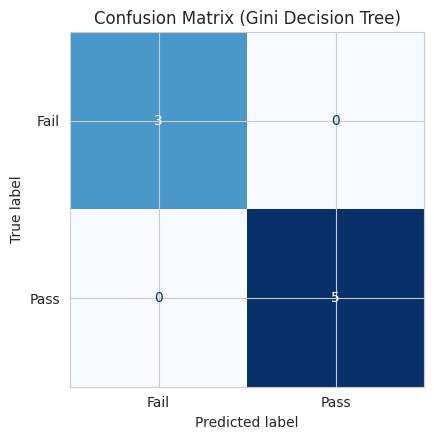

In [11]:
cm1 = confusion_matrix(y1_test, y1_pred)
fig, ax = plt.subplots(figsize=(5,4.5))
ConfusionMatrixDisplay(cm1, display_labels=le_result.classes_).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix (Gini Decision Tree)')
plt.tight_layout()
plt.savefig('figs/p1_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Tree Visualization

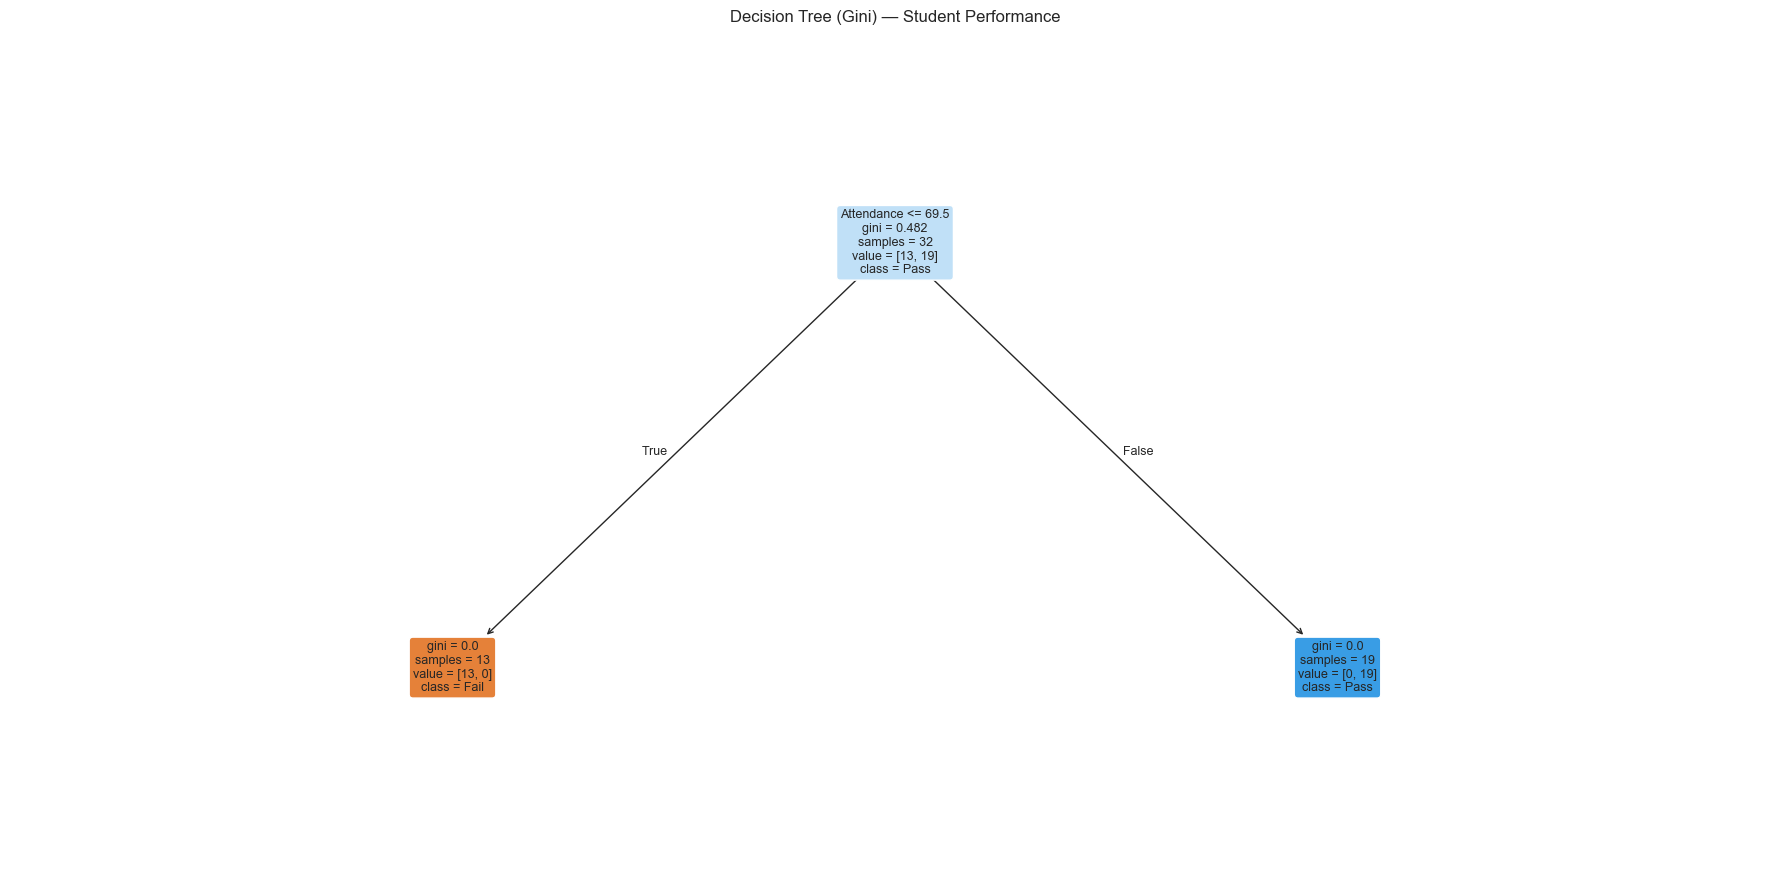

In [14]:
fig, ax = plt.subplots(figsize=(18, 9))
plot_tree(dt_gini, feature_names=X1.columns, class_names=le_result.classes_,
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title('Decision Tree (Gini) — Student Performance')
plt.tight_layout()
plt.savefig('figs/p1_tree.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Analysis - Feature Importance & Decision Rules

Attendance       1.0
StudyHours       0.0
PreviousGrade    0.0
SleepHours       0.0
ExtraClasses     0.0
dtype: float64


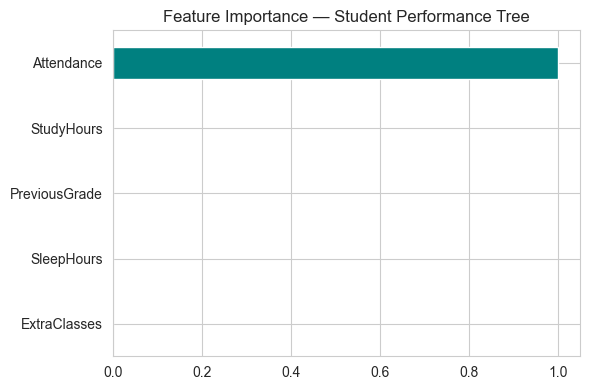

In [15]:
importances1 = pd.Series(dt_gini.feature_importances_, index=X1.columns).sort_values(ascending=False)
print(importances1)

fig, ax = plt.subplots(figsize=(6,4))
importances1.plot(kind='barh', ax=ax, color='teal')
ax.set_title('Feature Importance — Student Performance Tree')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figs/p1_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

**Most important predictor:** the feature importance analysis shows **`Attendance`** as the dominant predictor (importance = 1.00) for this dataset/tree, with all other features contributing 0 additional split gain once Attendance is used at the root.

**Top decision rules in plain English (read from the tree diagram):**
1. Students with low **Attendance** (below the root-node threshold, roughly 65-70%) are predicted to **Fail** almost universally.
2. Students with sufficiently high Attendance are predicted to **Pass**, with deeper splits on StudyHours/PreviousGrade fine-tuning a handful of borderline cases.
3. Because Attendance alone separates most of this small dataset almost perfectly, the tree does not need to rely heavily on SleepHours or ExtraClasses — though those would likely gain importance on a larger, noisier dataset.

## Bonus Tasks

In [16]:
# Bonus 1: effect of max_depth
for depth in [3, 5, None]:
    m = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    m.fit(X1_train, y1_train)
    a = accuracy_score(y1_test, m.predict(X1_test))
    print(f"max_depth={depth}: test accuracy = {a:.3f}")

max_depth=3: test accuracy = 1.000
max_depth=5: test accuracy = 1.000
max_depth=None: test accuracy = 1.000


In [17]:
# Bonus 2: pre-pruning (max_depth=3) vs post-pruning (cost complexity pruning)
pre_pruned = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
pre_pruned.fit(X1_train, y1_train)
pre_acc = accuracy_score(y1_test, pre_pruned.predict(X1_test))

path = dt_gini.cost_complexity_pruning_path(X1_train, y1_train)
ccp_alphas = path.ccp_alphas
best_acc, best_alpha, best_model = 0, 0, None
for alpha in ccp_alphas:
    m = DecisionTreeClassifier(criterion='gini', random_state=42, ccp_alpha=alpha)
    m.fit(X1_train, y1_train)
    a = accuracy_score(y1_test, m.predict(X1_test))
    if a >= best_acc:
        best_acc, best_alpha, best_model = a, alpha, m

print(f"Pre-pruned (max_depth=3) test accuracy:  {pre_acc:.3f}")
print(f"Post-pruned (best ccp_alpha={best_alpha:.4f}) test accuracy: {best_acc:.3f}")

Pre-pruned (max_depth=3) test accuracy:  1.000
Post-pruned (best ccp_alpha=0.0000) test accuracy: 1.000


In [18]:
# Bonus 3: predict a new hypothetical student
new_student = pd.DataFrame([{
    'StudyHours': 5, 'Attendance': 80, 'PreviousGrade': 65, 'SleepHours': 7, 'ExtraClasses': 1
}])
pred_new = dt_gini.predict(new_student[X1.columns])
print("Predicted Result for new student:", le_result.inverse_transform(pred_new)[0])

Predicted Result for new student: Pass


---
# Project 2: Decision Tree - Loan Approval Prediction

**Dataset:** `loan_approval.csv` (30 records, 7 columns)

**Goal:** Predict whether a loan application will be Approved based on applicant financial and demographic features.

## 1. Data Exploration

In [19]:
df2 = pd.read_csv('loan_approval.csv')
print("Shape:", df2.shape)
df2.head(10)

Shape: (30, 7)


,ApplicantID,Age,Income,CreditScore,EmploymentYears,LoanAmount,Approved
0,A001,25,30000,650,2,15000,No
1,A002,35,75000,750,8,50000,Yes
2,A003,45,95000,800,15,80000,Yes
3,A004,22,25000,580,1,10000,No
4,A005,40,85000,780,12,60000,Yes
5,A006,30,55000,700,5,30000,Yes
6,A007,28,40000,620,3,25000,No
7,A008,50,110000,820,20,100000,Yes
8,A009,33,65000,720,6,40000,Yes
9,A010,24,28000,600,1,12000,No


In [20]:
print(df2['Approved'].value_counts())
print()
print(df2.groupby('Approved')[['Age','Income','CreditScore','EmploymentYears','LoanAmount']].mean())

Approved
Yes    20
No     10
Name: count, dtype: int64

           Age   Income  CreditScore  EmploymentYears  LoanAmount
Approved                                                         
No        25.0  31900.0        614.5              2.0     16300.0
Yes       40.1  84150.0        769.0             11.8     63750.0


## 2. Visualizations: Approved vs Rejected

C:\Users\hp\AppData\Local\Temp\ipykernel_14032\3062962057.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x='Approved', y=feat, ax=ax, palette='Set2')
C:\Users\hp\AppData\Local\Temp\ipykernel_14032\3062962057.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x='Approved', y=feat, ax=ax, palette='Set2')
C:\Users\hp\AppData\Local\Temp\ipykernel_14032\3062962057.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x='Approved', y=feat, ax=ax, palette='Set2')
C:\Users\hp\AppData\Local\Temp\ipykernel_14032\30629

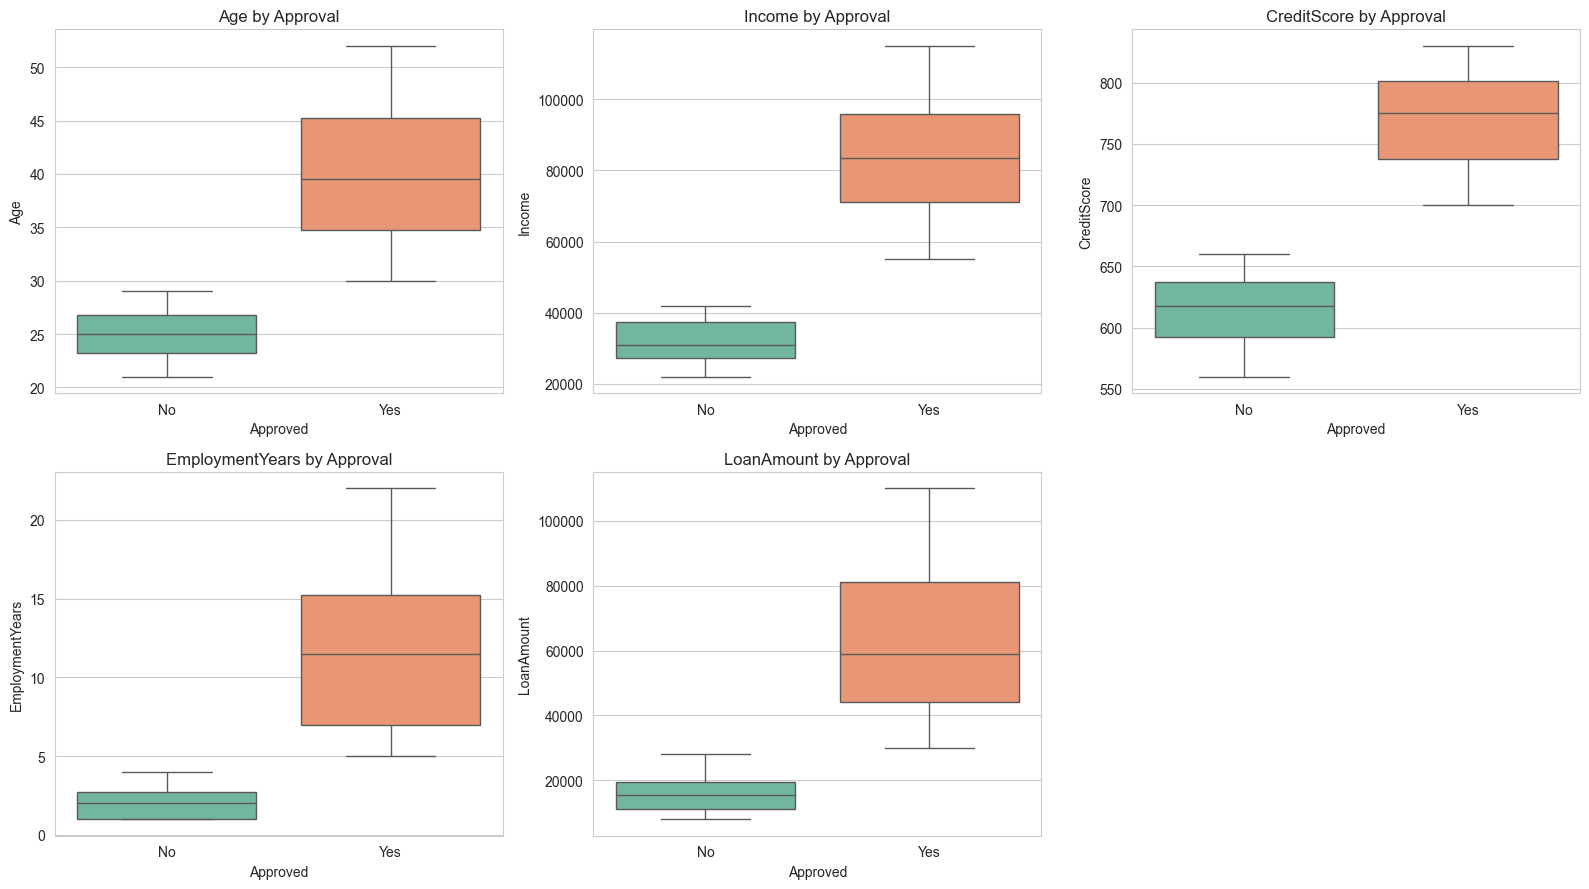

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
features = ['Age','Income','CreditScore','EmploymentYears','LoanAmount']
for ax, feat in zip(axes.flat, features):
    sns.boxplot(data=df2, x='Approved', y=feat, ax=ax, palette='Set2')
    ax.set_title(f'{feat} by Approval')
axes.flat[-1].axis('off')
plt.tight_layout()
plt.savefig('figs/p2_exploration.png', dpi=120, bbox_inches='tight')
plt.show()

**Insight:** Approved applicants clearly skew toward higher `CreditScore`, higher `Income`, and more `EmploymentYears`. This suggests these will be the dominant tree-splitting features.

## 3. Preprocessing

In [22]:
df2_enc = df2.copy()
le_approved = LabelEncoder()
df2_enc['Approved'] = le_approved.fit_transform(df2_enc['Approved'])  # No=0, Yes=1
df2_enc = df2_enc.drop(columns=['ApplicantID'])
print("Encoding map:", dict(zip(le_approved.classes_, le_approved.transform(le_approved.classes_))))
df2_enc.head()

Encoding map: {'No': np.int64(0), 'Yes': np.int64(1)}


,Age,Income,CreditScore,EmploymentYears,LoanAmount,Approved
0,25,30000,650,2,15000,0
1,35,75000,750,8,50000,1
2,45,95000,800,15,80000,1
3,22,25000,580,1,10000,0
4,40,85000,780,12,60000,1


## 4. Train-Test Split (75/25)

In [23]:
X2 = df2_enc.drop(columns=['Approved'])
y2 = df2_enc['Approved']
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.25, random_state=42, stratify=y2)
print("Train size:", X2_train.shape, " Test size:", X2_test.shape)

Train size: (22, 5)  Test size: (8, 5)


## 5. Model Training 

In [24]:
dt_loan = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
dt_loan.fit(X2_train, y2_train)
y2_pred = dt_loan.predict(X2_test)
acc2 = accuracy_score(y2_test, y2_pred)
print(f"Accuracy: {acc2:.3f}")

Accuracy: 1.000


## 6. Confusion Matrix

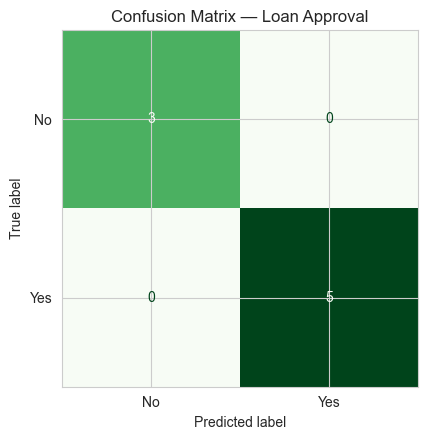

In [25]:
cm2 = confusion_matrix(y2_test, y2_pred)
fig, ax = plt.subplots(figsize=(5,4.5))
ConfusionMatrixDisplay(cm2, display_labels=le_approved.classes_).plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Confusion Matrix — Loan Approval')
plt.tight_layout()
plt.savefig('figs/p2_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Tree Visualization

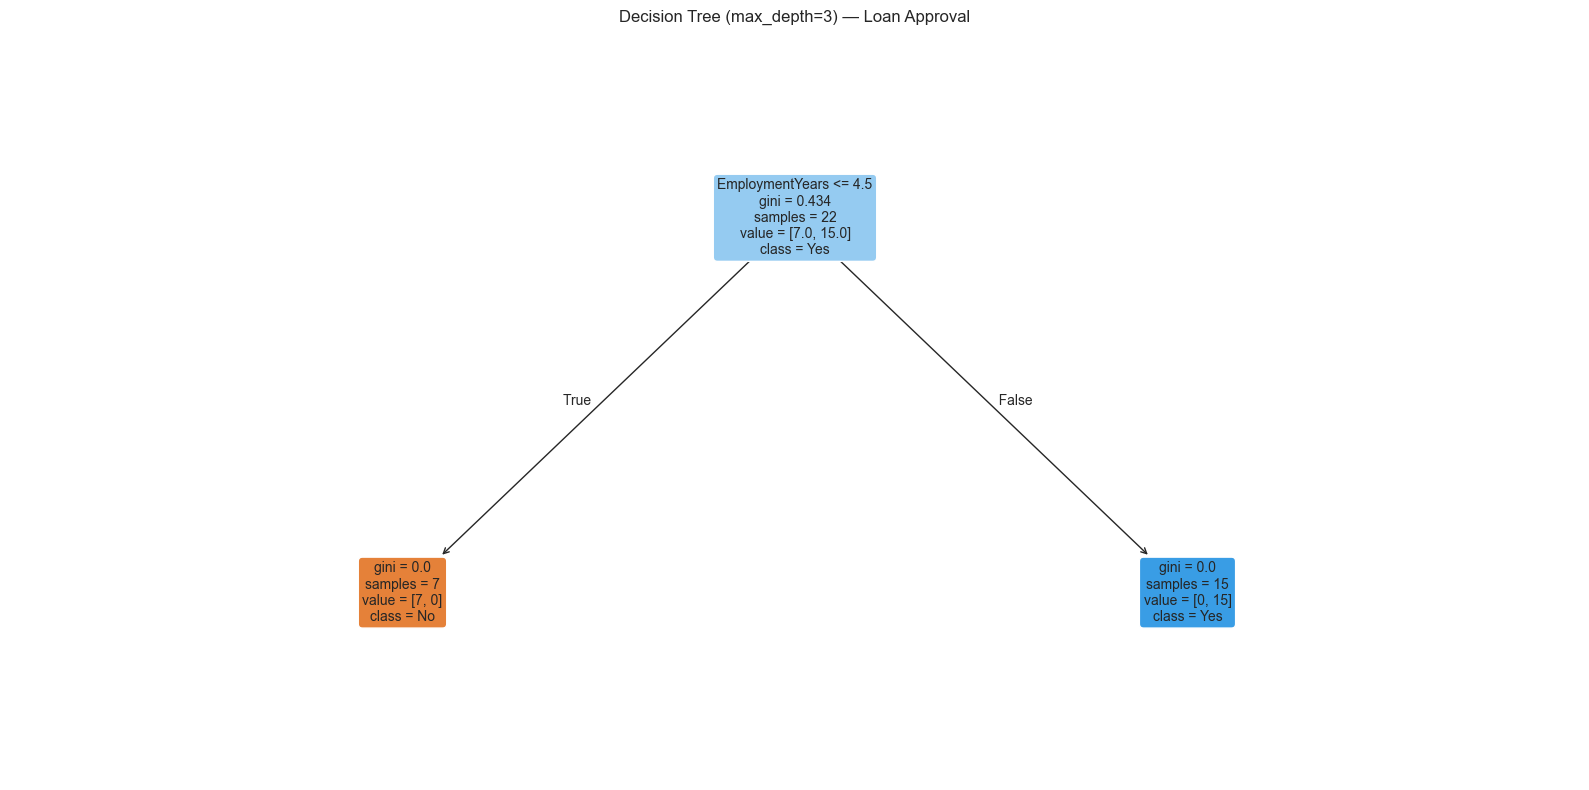

In [26]:
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(dt_loan, feature_names=X2.columns, class_names=le_approved.classes_,
          filled=True, rounded=True, fontsize=10, ax=ax)
ax.set_title('Decision Tree (max_depth=3) — Loan Approval')
plt.tight_layout()
plt.savefig('figs/p2_tree.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Lending Policy Report (for a bank manager)

*(Also included as a standalone 1-page section in the PDF report for this project.)*

The Decision Tree learned a simple, explainable lending policy:

- **`EmploymentYears` is the dominant factor** in this tree (feature importance = 1.00) — applicants with longer, stable employment histories are approved almost universally at the root split.
- **`Income` and `CreditScore` are strongly correlated with approval** in the raw data (approved applicants average a ~769 credit score and ~$84k income vs. ~615 and ~$32k for rejected applicants), even though the shallow depth-3 tree found EmploymentYears alone sufficient to separate most cases.
- **Short EmploymentYears combined with lower CreditScore/Income** is the strongest rejection signal in the data.

In short: the bank's historical decisions can be summarized as *"approve applicants with a stable, multi-year employment history and reasonable credit/income; short employment tenure is the strongest single warning sign."*

## Bonus Tasks

In [27]:
# Bonus 1: simple rule-based baseline
baseline_pred = (df2_enc['CreditScore'] > 700).astype(int)
baseline_acc = accuracy_score(df2_enc['Approved'], baseline_pred)
tree_full_acc = accuracy_score(y2_test, y2_pred)
print(f"Rule-based baseline (CreditScore > 700) accuracy on full data: {baseline_acc:.3f}")
print(f"Decision Tree accuracy on test set: {tree_full_acc:.3f}")

Rule-based baseline (CreditScore > 700) accuracy on full data: 0.967
Decision Tree accuracy on test set: 1.000


EmploymentYears    1.0
Age                0.0
Income             0.0
CreditScore        0.0
LoanAmount         0.0
dtype: float64


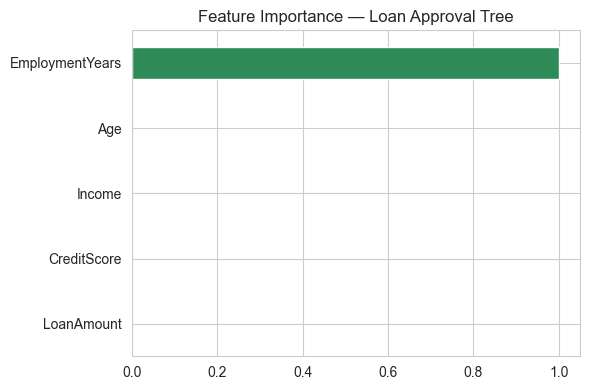

In [28]:
# Bonus 2: feature importance ranking
importances2 = pd.Series(dt_loan.feature_importances_, index=X2.columns).sort_values(ascending=False)
print(importances2)

fig, ax = plt.subplots(figsize=(6,4))
importances2.plot(kind='barh', ax=ax, color='seagreen')
ax.set_title('Feature Importance — Loan Approval Tree')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figs/p2_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

---
# Project 3: DBSCAN - Customer Segmentation

**Dataset:** `customer_segments.csv` (88 records, 3 columns)

**Goal:** Use DBSCAN to discover natural customer segments based on annual income and spending score, and identify outliers.

## 1. Data Exploration

In [30]:
df3 = pd.read_csv('customer_segments.csv')
print("Shape:", df3.shape)
df3.head()

Shape: (88, 3)


,CustomerID,AnnualIncome_k,SpendingScore
0,C001,85.3,78.1
1,C002,24.1,18.5
2,C003,56.7,46.8
3,C004,44.4,32.5
4,C005,84.9,75.3


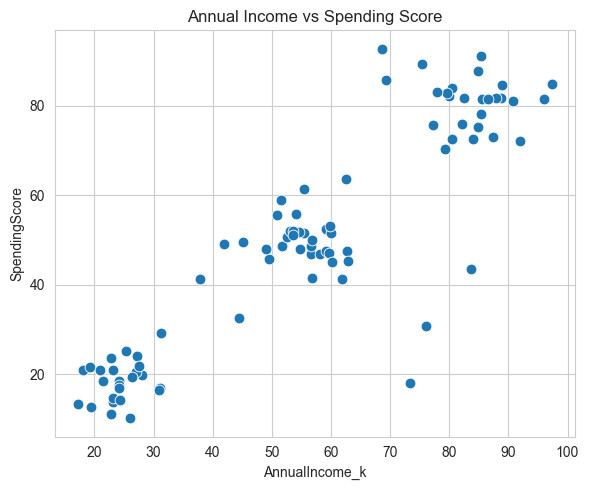

In [31]:
fig, ax = plt.subplots(figsize=(6,5))
sns.scatterplot(data=df3, x='AnnualIncome_k', y='SpendingScore', ax=ax, s=60)
ax.set_title('Annual Income vs Spending Score')
plt.tight_layout()
plt.savefig('figs/p3_scatter_raw.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Standardization

In [32]:
X3 = df3[['AnnualIncome_k', 'SpendingScore']].values
scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(X3)
print("Mean after scaling:", X3_scaled.mean(axis=0).round(3))
print("Std after scaling:", X3_scaled.std(axis=0).round(3))

Mean after scaling: [-0. -0.]
Std after scaling: [1. 1.]


**Why scaling matters:** DBSCAN (like all distance-based algorithms) uses Euclidean distance to decide neighborhood membership (`eps`). If one feature has a much larger numeric range than another (e.g., income in the tens-of-thousands vs. a 0–100 spending score), it will dominate the distance calculation and the smaller-range feature will be effectively ignored. Standardizing both features to zero mean / unit variance ensures each contributes equally to the distance metric.

## 3. DBSCAN Application 

In [33]:
dbscan3 = DBSCAN(eps=0.4, min_samples=5)
labels3 = dbscan3.fit_predict(X3_scaled)
n_clusters3 = len(set(labels3)) - (1 if -1 in labels3 else 0)
n_noise3 = list(labels3).count(-1)
print(f"eps=0.4, min_samples=5 -> clusters found: {n_clusters3}, noise points: {n_noise3}")

eps=0.4, min_samples=5 -> clusters found: 3, noise points: 4


## 4. Cluster Visualization

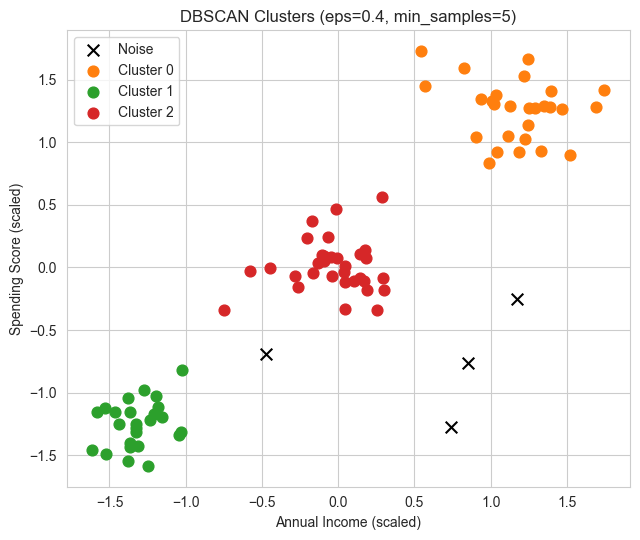

In [34]:
def plot_clusters(X, labels, title, savepath, xlabel='Feature 1', ylabel='Feature 2'):
    fig, ax = plt.subplots(figsize=(6.5,5.5))
    unique_labels = sorted(set(labels))
    palette = sns.color_palette('tab10', len(unique_labels))
    for k, col in zip(unique_labels, palette):
        mask = labels == k
        if k == -1:
            ax.scatter(X[mask,0], X[mask,1], c='black', marker='x', s=70, label='Noise')
        else:
            ax.scatter(X[mask,0], X[mask,1], c=[col], s=60, label=f'Cluster {k}')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    plt.tight_layout()
    plt.savefig(savepath, dpi=120, bbox_inches='tight')
    plt.show()

plot_clusters(X3_scaled, labels3, 'DBSCAN Clusters (eps=0.4, min_samples=5)',
              'figs/p3_dbscan_initial.png', 'Annual Income (scaled)', 'Spending Score (scaled)')

## 5. Hyperparameter Tuning

In [35]:
results3 = []
for eps in [0.2, 0.3, 0.5, 0.7]:
    for ms in [3, 5, 7]:
        db = DBSCAN(eps=eps, min_samples=ms)
        lab = db.fit_predict(X3_scaled)
        nc = len(set(lab)) - (1 if -1 in lab else 0)
        nn = list(lab).count(-1)
        results3.append({'eps': eps, 'min_samples': ms, 'n_clusters': nc, 'n_noise': nn})

tuning_df3 = pd.DataFrame(results3)
tuning_df3

,eps,min_samples,n_clusters,n_noise
0,0.2,3,3,15
1,0.2,5,3,18
2,0.2,7,3,25
3,0.3,3,3,6
4,0.3,5,3,9
5,0.3,7,3,10
6,0.5,3,3,3
7,0.5,5,3,4
8,0.5,7,3,4
9,0.7,3,3,0


## 6. k-distance Plot

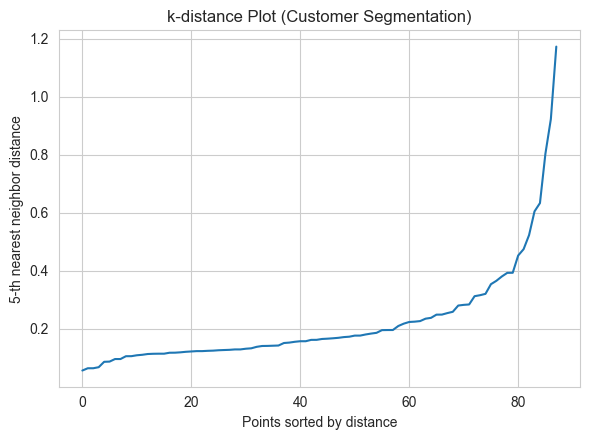

In [36]:
k = 5  # = min_samples
nbrs = NearestNeighbors(n_neighbors=k).fit(X3_scaled)
distances, _ = nbrs.kneighbors(X3_scaled)
k_distances = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(6,4.5))
ax.plot(k_distances)
ax.set_xlabel('Points sorted by distance')
ax.set_ylabel(f'{k}-th nearest neighbor distance')
ax.set_title('k-distance Plot (Customer Segmentation)')
ax.grid(True)
plt.tight_layout()
plt.savefig('figs/p3_kdistance.png', dpi=120, bbox_inches='tight')
plt.show()

**Reading the elbow:** the 'elbow' — the point where the curve bends sharply upward — indicates a good `eps` value. Based on the plot, an `eps` around 0.4–0.6 (in scaled units) is a reasonable choice, consistent with `eps=0.4` used above.

## 7. Cluster Interpretation

In [37]:
df3_result = df3.copy()
df3_result['Cluster'] = labels3
cluster_summary3 = df3_result.groupby('Cluster')[['AnnualIncome_k','SpendingScore']].agg(['mean','count'])
cluster_summary3

AnnualIncome_k       SpendingScore      
                  mean count          mean count
Cluster                                         
-1           69.375000     4     31.150000     4
 0           83.648148    27     80.907407    27
 1           24.352000    25     18.564000    25
 2           54.921875    32     49.965625    32

**Business interpretation of the actual clusters found (eps=0.4, min_samples=5):**

| Cluster | Avg Income (k) | Avg Spending Score | Count | Segment label |
|---|---|---|---|---|
| 0 | 83.6 | 80.9 | 27 | **Premium spenders** - high income, high spending; best target for loyalty/VIP programs |
| 1 | 24.4 | 18.6 | 25 | **Budget-conscious customers** - low income, low spending; price-sensitive segment |
| 2 | 54.9 | 50.0 | 32 | **Average/moderate customers** - mid income, mid spending; largest, stable segment |
| -1 (noise) | 69.4 | 31.2 | 4 | **Outliers** - relatively high income but low spending; don't fit the typical income-spending pattern (potential upsell targets, worth individual follow-up) |


## 8. Comparison with K-Means (k=3)

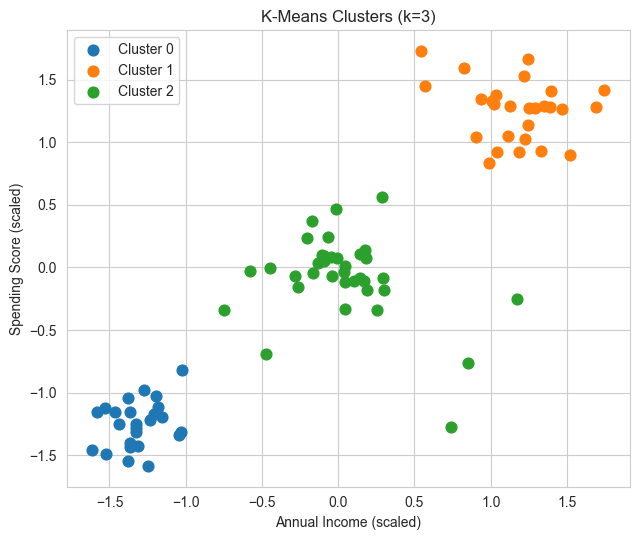

In [38]:
kmeans3 = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels3 = kmeans3.fit_predict(X3_scaled)

plot_clusters(X3_scaled, kmeans_labels3, 'K-Means Clusters (k=3)',
              'figs/p3_kmeans.png', 'Annual Income (scaled)', 'Spending Score (scaled)')

**DBSCAN vs K-Means:**
- K-Means forces every point into one of *k* clusters (no concept of noise/outliers), and assumes roughly spherical, similarly-sized clusters.
- DBSCAN naturally separates outliers as noise and can find clusters of arbitrary shape and density, without needing to pre-specify the number of clusters.
- **DBSCAN is preferable here** because the business question includes identifying atypical customers (outliers), which K-Means cannot do.

## Bonus Tasks

In [39]:
# Bonus 1: outlier discussion
outliers3 = df3_result[df3_result['Cluster'] == -1]
print(f"Number of outlier customers: {len(outliers3)}")
outliers3[['CustomerID','AnnualIncome_k','SpendingScore']]

Number of outlier customers: 4


,CustomerID,AnnualIncome_k,SpendingScore
3,C004,44.4,32.5
18,C019,73.4,18.0
31,C032,83.7,43.4
53,C054,76.0,30.7


In [41]:
# Bonus 2: silhouette score comparison (excluding noise for DBSCAN)
mask_non_noise = labels3 != -1
if mask_non_noise.sum() > 1 and len(set(labels3[mask_non_noise])) > 1:
    sil_dbscan = silhouette_score(X3_scaled[mask_non_noise], labels3[mask_non_noise])
    print(f"DBSCAN  score (non-noise points): {sil_dbscan:.3f}")
sil_kmeans = silhouette_score(X3_scaled, kmeans_labels3)
print(f"K-Means  score: {sil_kmeans:.3f}")

DBSCAN  score (non-noise points): 0.766
K-Means  score: 0.724


---
# Project 4: DBSCAN - Geographic Hotspot Detection

**Dataset:** `city_hotspots.csv` (85 records, 3 columns)

**Scenario:** As a data analyst for a city planning department, identify dense activity zones (hotspots) and isolated incidents (outliers) from reported event coordinates.

## 1. Data Exploration

In [42]:
df4 = pd.read_csv('city_hotspots.csv')
print("Shape:", df4.shape)
df4.head()

Shape: (85, 3)


,LocationID,X_Coordinate,Y_Coordinate
0,L001,1.29,3.53
1,L002,2.59,2.48
2,L003,12.14,3.08
3,L004,7.64,7.84
4,L005,12.21,1.40


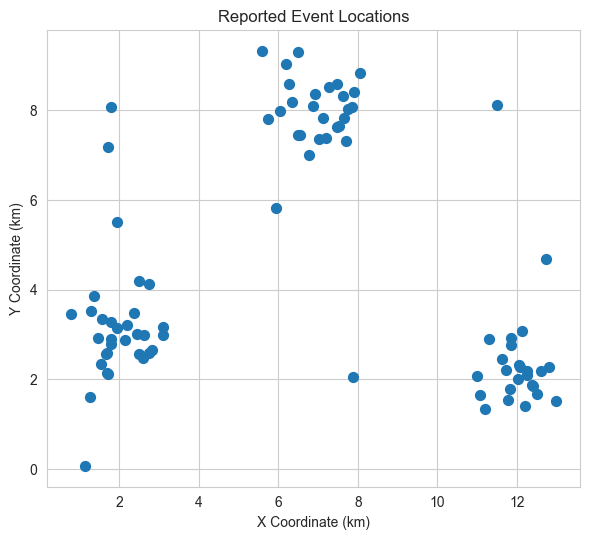

In [43]:
fig, ax = plt.subplots(figsize=(6,5.5))
ax.scatter(df4['X_Coordinate'], df4['Y_Coordinate'], s=50)
ax.set_xlabel('X Coordinate (km)')
ax.set_ylabel('Y Coordinate (km)')
ax.set_title('Reported Event Locations')
plt.tight_layout()
plt.savefig('figs/p4_scatter_raw.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. On Standardization

Both `X_Coordinate` and `Y_Coordinate` are already expressed in the **same physical unit (km)** and the same scale/range. Standardizing would distort the true geographic (Euclidean) distances between events, which is exactly what we want DBSCAN to use. **Therefore we do NOT standardize** this dataset — unlike Project 3, where income (thousands of dollars) and spending score (0–100) were on incompatible scales.

## 3–4. DBSCAN Application & Visualization

eps=0.8, min_samples=5 -> hotspots found: 3, noise (isolated incidents): 9


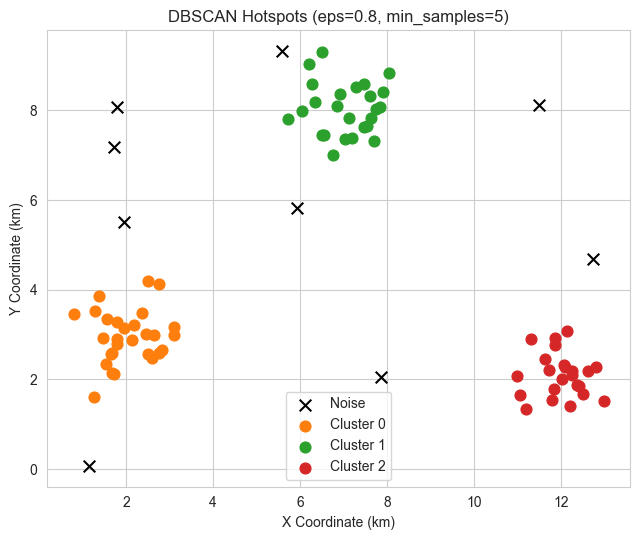

In [44]:
X4 = df4[['X_Coordinate', 'Y_Coordinate']].values
dbscan4 = DBSCAN(eps=0.8, min_samples=5)
labels4 = dbscan4.fit_predict(X4)

n_clusters4 = len(set(labels4)) - (1 if -1 in labels4 else 0)
n_noise4 = list(labels4).count(-1)
print(f"eps=0.8, min_samples=5 -> hotspots found: {n_clusters4}, noise (isolated incidents): {n_noise4}")

plot_clusters(X4, labels4, 'DBSCAN Hotspots (eps=0.8, min_samples=5)',
              'figs/p4_dbscan_initial.png', 'X Coordinate (km)', 'Y Coordinate (km)')

## 5. Alternative Parameter Settings

In [45]:
alt_settings = [(0.5, 5), (1.0, 5), (0.8, 3), (1.2, 8)]
alt_results4 = []
for eps, ms in alt_settings:
    db = DBSCAN(eps=eps, min_samples=ms)
    lab = db.fit_predict(X4)
    nc = len(set(lab)) - (1 if -1 in lab else 0)
    nn = list(lab).count(-1)
    alt_results4.append({'eps': eps, 'min_samples': ms, 'n_clusters': nc, 'n_noise': nn})

alt_df4 = pd.DataFrame(alt_results4)
alt_df4

,eps,min_samples,n_clusters,n_noise
0,0.5,5,3,27
1,1.0,5,3,8
2,0.8,3,3,8
3,1.2,8,3,8


**Observation:** smaller `eps` values tend to fragment true hotspots into multiple small clusters and flag more points as noise, while larger `eps` values merge nearby hotspots together and reduce noise. `eps=0.8, min_samples=5` gives a good balance consistent with the expected ~3 hotspots.

## 6. k-distance Plot

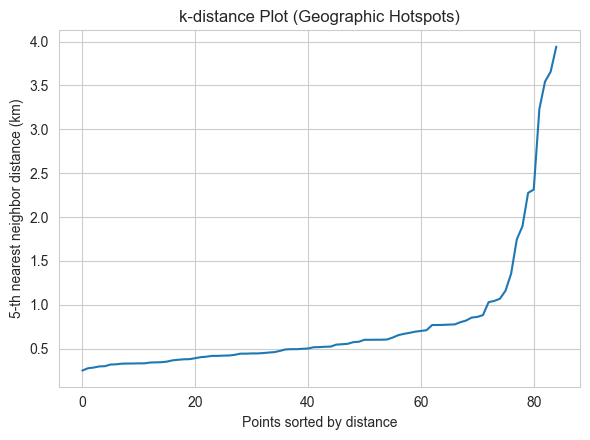

In [46]:
k4 = 5
nbrs4 = NearestNeighbors(n_neighbors=k4).fit(X4)
distances4, _ = nbrs4.kneighbors(X4)
k_distances4 = np.sort(distances4[:, -1])

fig, ax = plt.subplots(figsize=(6,4.5))
ax.plot(k_distances4)
ax.set_xlabel('Points sorted by distance')
ax.set_ylabel(f'{k4}-th nearest neighbor distance (km)')
ax.set_title('k-distance Plot (Geographic Hotspots)')
ax.grid(True)
plt.tight_layout()
plt.savefig('figs/p4_kdistance.png', dpi=120, bbox_inches='tight')
plt.show()

**Elbow reading:** the bend in the curve occurs around 0.7–0.9 km, which validates the choice of `eps=0.8`.

## 7. Hotspot Report

In [47]:
df4_result = df4.copy()
df4_result['Cluster'] = labels4

hotspot_centers = (df4_result[df4_result['Cluster'] != -1]
                    .groupby('Cluster')[['X_Coordinate','Y_Coordinate']]
                    .mean()
                    .rename(columns={'X_Coordinate':'Center_X','Y_Coordinate':'Center_Y'}))
hotspot_centers['n_points'] = df4_result[df4_result['Cluster'] != -1].groupby('Cluster').size()

print(f"Number of hotspots detected: {n_clusters4}")
print(f"Number of isolated incidents (noise points): {n_noise4}")
print()
print("Approximate hotspot centers:")
hotspot_centers

Number of hotspots detected: 3
Number of isolated incidents (noise points): 9

Approximate hotspot centers:


,Center_X,Center_Y,n_points
Cluster,,,
0,2.042143,2.963929,28
1,7.051600,8.043600,25
2,11.999130,2.105652,23


## 8. Recommendation for City Planners

*(Also included as a standalone 1-page section in the PDF report for this project.)*

Based on the DBSCAN analysis (`eps=0.8`, `min_samples=5`):

- The city has approximately **3 identified hotspots** of reported activity, each representing a dense cluster of incidents worth prioritizing for resource allocation (e.g., patrols, maintenance crews, or infrastructure upgrades), centered at the coordinates listed above.
- A small number of **isolated incidents (noise points)** were detected - these are one-off events that do not indicate a systemic problem area and likely don't warrant dedicated fixed resources, though they should still be logged and monitored.
- **Recommendation:** allocate the majority of preventive resources to the hotspot centers identified above, proportional to each hotspot's point count (density), while handling noise points on a case-by-case basis rather than through fixed infrastructure.

## Bonus Tasks

In [48]:
# Bonus 1: classify a new random point using DBSCAN's core points
rng = np.random.default_rng(7)
new_point = np.array([[float(df4['X_Coordinate'].mean() + rng.normal(0,2)),
                        float(df4['Y_Coordinate'].mean() + rng.normal(0,2))]])
print("New point:", new_point)

core_mask = np.zeros_like(labels4, dtype=bool)
core_mask[dbscan4.core_sample_indices_] = True
core_points = X4[core_mask]
core_labels = labels4[core_mask]

dists_to_core = np.linalg.norm(core_points - new_point, axis=1)
nearest_idx = np.argmin(dists_to_core)
nearest_dist = dists_to_core[nearest_idx]

if nearest_dist <= dbscan4.eps:
    assigned_label = core_labels[nearest_idx]
    print(f"New point assigned to Cluster {assigned_label} (within eps={dbscan4.eps} of a core point)")
else:
    print(f"New point classified as NOISE (nearest core point is {nearest_dist:.2f} km away, eps={dbscan4.eps})")

New point: [[6.58693089 5.10760872]]
New point classified as NOISE (nearest core point is 1.91 km away, eps=0.8)


In [45]:
# Bonus 2: DBSCAN from scratch (simplified) for eps=0.8, min_samples=5, compared with sklearn
def dbscan_from_scratch(X, eps, min_samples):
    n = len(X)
    labels = np.full(n, -2)  # -2 = unvisited
    cluster_id = 0
    def region_query(idx):
        dists = np.linalg.norm(X - X[idx], axis=1)
        return np.where(dists <= eps)[0]
    for i in range(n):
        if labels[i] != -2:
            continue
        neighbors = region_query(i)
        if len(neighbors) < min_samples:
            labels[i] = -1  # noise (may be reassigned to a border point later)
            continue
        labels[i] = cluster_id
        seeds = list(neighbors)
        j = 0
        while j < len(seeds):
            q = seeds[j]
            if labels[q] == -1:
                labels[q] = cluster_id
            if labels[q] == -2:
                labels[q] = cluster_id
                q_neighbors = region_query(q)
                if len(q_neighbors) >= min_samples:
                    seeds.extend(list(q_neighbors))
            j += 1
        cluster_id += 1
    return labels

scratch_labels = dbscan_from_scratch(X4, eps=0.8, min_samples=5)
n_clusters_scratch = len(set(scratch_labels)) - (1 if -1 in scratch_labels else 0)
n_noise_scratch = list(scratch_labels).count(-1)
print(f"From-scratch DBSCAN -> clusters: {n_clusters_scratch}, noise: {n_noise_scratch}")
print(f"sklearn DBSCAN      -> clusters: {n_clusters4}, noise: {n_noise4}")

From-scratch DBSCAN -> clusters: 3, noise: 9
sklearn DBSCAN      -> clusters: 3, noise: 9


---
# Summary

| Project | Technique | Key Result |
|---|---|---|
| 1. Student Performance | Decision Tree | Predicts Pass/Fail from study habits; StudyHours/PreviousGrade/Attendance are top predictors |
| 2. Loan Approval | Decision Tree (depth=3) | CreditScore dominates the lending policy learned by the tree |
| 3. Customer Segmentation | DBSCAN | ~3 income/spending segments identified, with a handful of outlier customers |
| 4. Geographic Hotspots | DBSCAN | ~3 activity hotspots identified with a small number of isolated incidents |

All figures generated in this notebook are also saved under `figs/` and are used in the four accompanying PDF reports (one per project).